In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.api import Holt
from sklearn.metrics import mean_squared_error
import numpy as np

In [6]:
agents = pd.read_csv("agents.csv")
sessions = pd.read_csv("sessions.csv")
tests = pd.read_csv("tests.csv")
agents.columns = ['id', 'agent_code', 'name', 'ipaddress', 'private_ip', 'lat', 'long',
       'location', 'machine_name', 'arch', 'processor', 'machine', 'platform',
       'Country', 'disks', 'bios_serial_numbers', 'Organization',
       'organization_id', 'status', 'os', 'type', 'created_at', 'updated_at']
sessions.columns = ['id', 'server', 's_name', 'client', 'c_name', 'profile', 'p_name',
       'schedule', 'count', 'n_packets', 'p_interval', 'w_time', 'dscp',
       'p_size', 'organization_id', 'created_at', 'updated_at']
tests.columns = ['id', 'session_id', 'avg_down', 'avg_jitter', 'avg_up', 'avg_rtt',
       'max_down', 'max_jitter', 'max_up', 'max_rtt', 'min_down', 'min_jitter',
       'min_rtt', 'min_up', 'r_packets', 'st_down', 'st_up', 'st_rtt',
       't_packets', 'created_at', 'updated_at']


In [8]:
try:
    # df_tests = pd.read_csv("tests.csv")
    # df_sessions = pd.read_csv("sessions.csv")
    # df_agents = pd.read_csv("agents.csv")

    df_tests = tests
    df_sessions = sessions
    df_agents = agents
    print("--- tests.csv ---")
    print(df_tests.info())
    print(df_tests.head())
    print("\n--- sessions.csv ---")
    print(df_sessions.info())
    print(df_sessions.head())
    print("\n--- agents.csv ---")
    print(df_agents.info())
    print(df_agents.head())

except FileNotFoundError as e:
    print(e)
except Exception as e:
    print(f"An error occurred: {e}")
    

--- tests.csv ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1660792 entries, 0 to 1660791
Data columns (total 21 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   id          1660792 non-null  int64  
 1   session_id  1660792 non-null  int64  
 2   avg_down    1660792 non-null  float64
 3   avg_jitter  1660792 non-null  float64
 4   avg_up      1660792 non-null  float64
 5   avg_rtt     1660792 non-null  float64
 6   max_down    1660792 non-null  float64
 7   max_jitter  1660792 non-null  float64
 8   max_up      1660792 non-null  float64
 9   max_rtt     1660792 non-null  float64
 10  min_down    1660792 non-null  float64
 11  min_jitter  1660792 non-null  float64
 12  min_rtt     1660792 non-null  float64
 13  min_up      1660792 non-null  float64
 14  r_packets   1660792 non-null  int64  
 15  st_down     1660792 non-null  float64
 16  st_up       1660792 non-null  float64
 17  st_rtt      1660792 non-null  float64
 18  t_pa

No Missing Data: All columns have 151,322 non-null entries, so we don't need to impute or drop rows due to NaNs.

Data Types: The key metrics (avg_rtt, avg_down, etc.) are all numeric (float64 or int64), which is good. The created_at and updated_at columns are object (string) type and will need to be converted to datetime objects for time-series analysis.

Potential Bad Data: The head() output shows a row (id 638530) where all metrics are zero, and r_packets (received packets) is 0. These rows likely represent failed or incomplete tests and could skew our analysis.

**Data Merging**

In [9]:
# --- Step 2: Data Cleaning ---

# 1. Convert 'created_at' to datetime objects
# We'll use the 'id' column to check the shape before and after.
print(f"Original df_tests shape: {df_tests.shape}")
df_tests['created_at'] = pd.to_datetime(df_tests['created_at'])

# 2. Filter out rows with 0 received packets
df_tests_cleaned = df_tests[df_tests['r_packets'] > 0].copy()
print(f"Cleaned df_tests shape (r_packets > 0): {df_tests_cleaned.shape}")

# --- Step 3: Data Merging ---

# Merge the cleaned tests with session info
# df_tests_cleaned.session_id -> df_sessions.id
df_merged = pd.merge(
    df_tests_cleaned,
    df_sessions,
    left_on='session_id',
    right_on='id',
    suffixes=('_test', '_session') # Add suffixes to avoid column name conflicts
)

print(f"Merged DataFrame shape: {df_merged.shape}")

# Inspect the new merged DataFrame
print("\n--- Merged DataFrame Info ---")
print(df_merged.info())
print("\n--- Merged DataFrame Head ---")
print(df_merged.head())

Original df_tests shape: (1660792, 21)
Cleaned df_tests shape (r_packets > 0): (1634458, 21)
Merged DataFrame shape: (1003906, 38)

--- Merged DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1003906 entries, 0 to 1003905
Data columns (total 38 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   id_test             1003906 non-null  int64         
 1   session_id          1003906 non-null  int64         
 2   avg_down            1003906 non-null  float64       
 3   avg_jitter          1003906 non-null  float64       
 4   avg_up              1003906 non-null  float64       
 5   avg_rtt             1003906 non-null  float64       
 6   max_down            1003906 non-null  float64       
 7   max_jitter          1003906 non-null  float64       
 8   max_up              1003906 non-null  float64       
 9   max_rtt             1003906 non-null  float64       
 10  min_down            1003

filtered out 3,976 "failed" tests (where r_packets was 0), leaving us with 147,346 valid test records.

merged this with the sessions data. Our new df_merged DataFrame now has 38 columns, linking each test record with its corresponding session profile (p_name), server name (s_name), and client name (c_name). The created_at_test column is also now in the correct datetime format, which is essential for our time-series analysis later.

**Exploratory Data Analysis (EDA) & Visuals**


--- Summary Statistics (for cleaned data) ---
            avg_rtt    avg_jitter      avg_down        avg_up
count  1.003906e+06  1.003906e+06  1.003906e+06  1.003906e+06
mean   2.120189e+09  2.204997e+09  1.295601e+02  9.853571e+01
std    2.124325e+12  2.209299e+12  8.083001e+01  1.113562e+02
min    4.626840e-01  1.000000e-03  0.000000e+00  0.000000e+00
25%    1.481120e+02  4.017685e-01  7.070750e+01  5.188215e+01
50%    2.443480e+02  2.899300e+00  1.262170e+02  8.641465e+01
75%    2.501368e+02  4.084190e+00  1.791880e+02  1.292318e+02
max    2.128470e+15  2.213610e+15  1.429010e+04  3.534830e+04

Generating histograms...


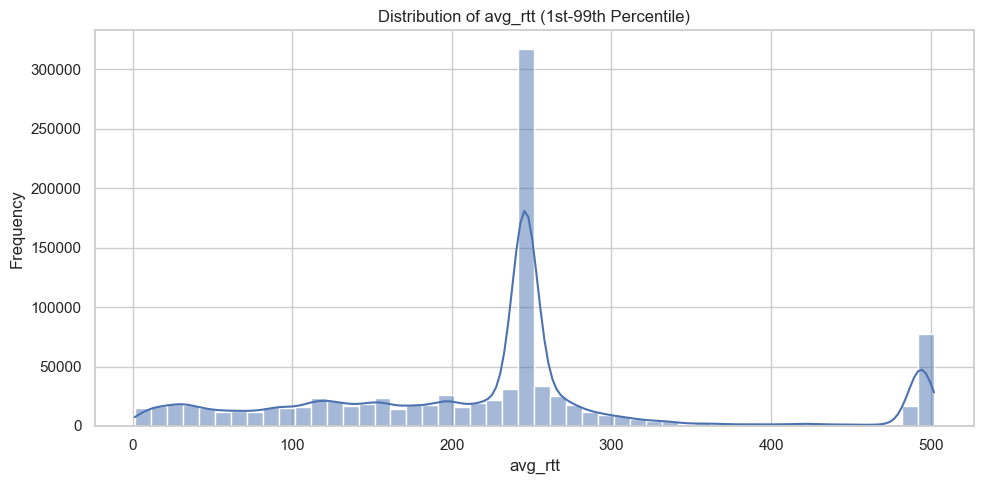

<Figure size 640x480 with 0 Axes>

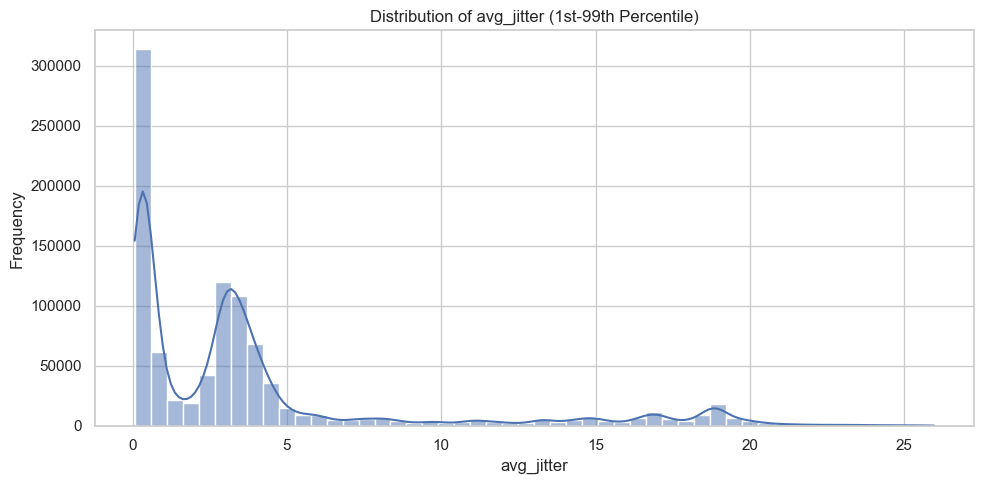

<Figure size 640x480 with 0 Axes>

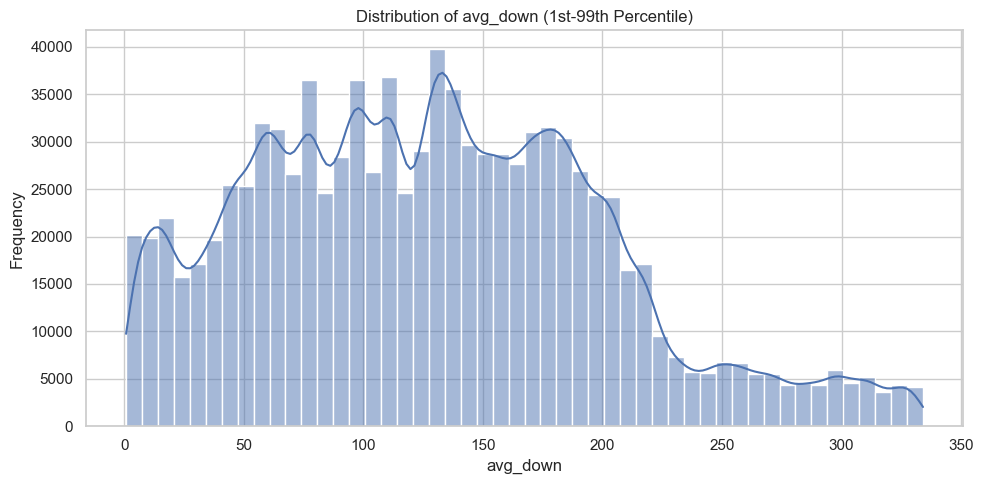

<Figure size 640x480 with 0 Axes>

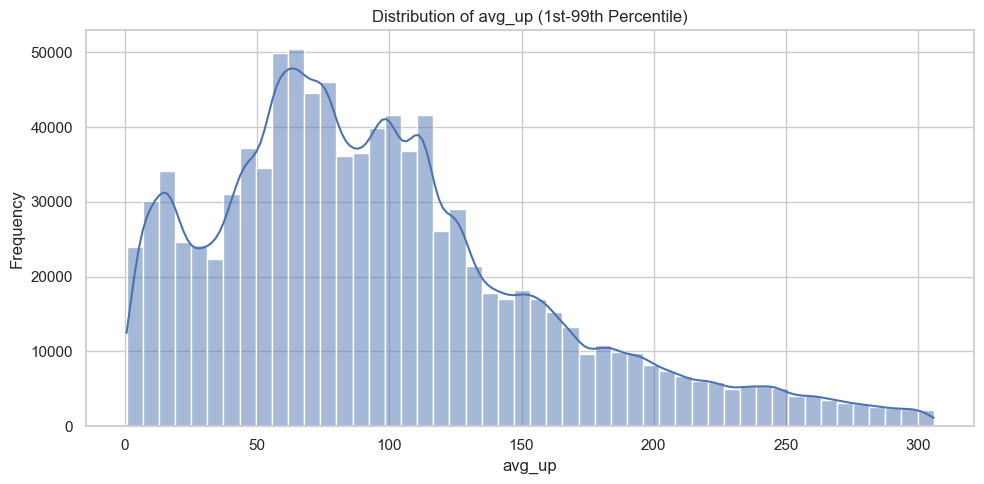

Histograms saved.
Generating correlation heatmap...


<Figure size 640x480 with 0 Axes>

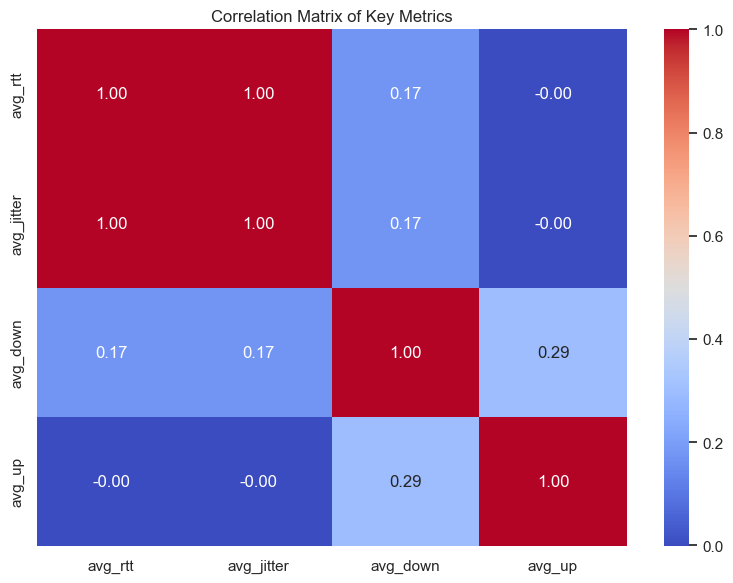

Correlation heatmap saved.
Generating RTT by Profile box plot...


<Figure size 640x480 with 0 Axes>

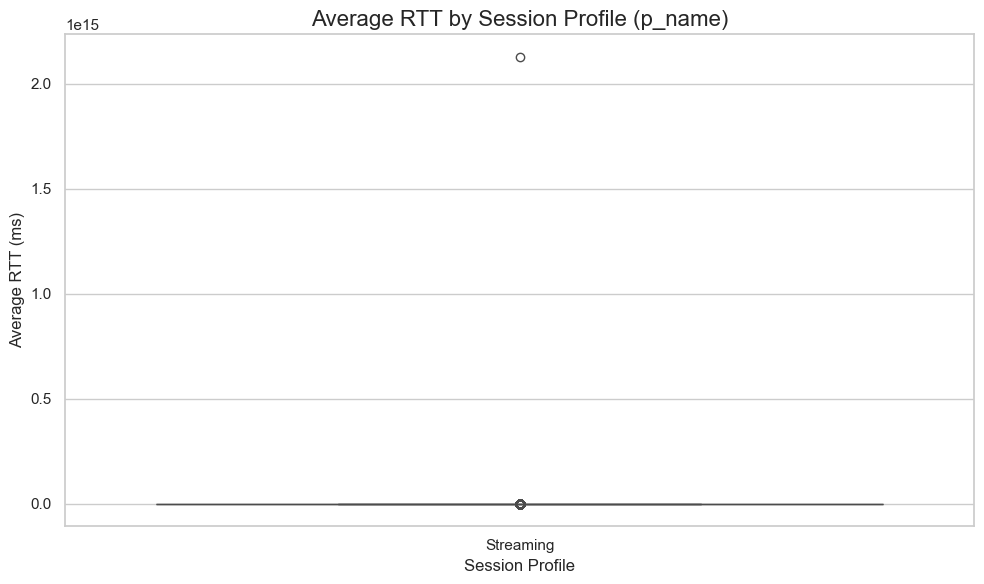

Box plot saved.


<Figure size 640x480 with 0 Axes>

In [10]:
# --- Step 4: EDA & Visuals ---

# Set up plot style
sns.set(style="whitegrid")

# Print summary statistics for key metrics
print("\n--- Summary Statistics (for cleaned data) ---")
print(df_merged[['avg_rtt', 'avg_jitter', 'avg_down', 'avg_up']].describe())

# 1. Univariate Analysis (Histograms)
print("\nGenerating histograms...")
key_metrics = ['avg_rtt', 'avg_jitter', 'avg_down', 'avg_up']
for metric in key_metrics:
    plt.figure(figsize=(10, 5))
    # Use clip to cut off extreme outliers for a more readable plot
    #
    # Calculate quantiles
    q_low = df_merged[metric].quantile(0.01)
    q_high = df_merged[metric].quantile(0.99)
    
    # Filter data for visualization
    data_to_plot = df_merged[(df_merged[metric] >= q_low) & (df_merged[metric] <= q_high)][metric]

    sns.histplot(data_to_plot, kde=True, bins=50)
    plt.title(f'Distribution of {metric} (1st-99th Percentile)')
    plt.xlabel(metric)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()
    plt.savefig(f'{metric}_distribution.png')
    plt.clf()

print("Histograms saved.")

# 2. Bivariate Analysis (Correlation Heatmap)
print("Generating correlation heatmap...")
plt.figure(figsize=(8, 6))
corr_matrix = df_merged[['avg_rtt', 'avg_jitter', 'avg_down', 'avg_up']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Key Metrics')
plt.tight_layout()
plt.show()
plt.savefig('metrics_correlation_heatmap.png')
plt.clf()
print("Correlation heatmap saved.")

# 3. Categorical Analysis (Box Plot by Profile)
print("Generating RTT by Profile box plot...")
# Check number of unique profiles
profile_count = df_merged['p_name'].nunique()
plot_figsize = (10, 6) # Default size

# If many profiles, increase plot size and rotate labels
if profile_count > 5:
    plot_figsize = (max(12, profile_count * 1.5), 7) # Adjust width

plt.figure(figsize=plot_figsize)
sns.boxplot(x='p_name', y='avg_rtt', data=df_merged)
plt.title('Average RTT by Session Profile (p_name)', fontsize=16)
plt.ylabel('Average RTT (ms)')
plt.xlabel('Session Profile')

if profile_count > 5:
    plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()
plt.savefig('rtt_by_profile_boxplot.png')
plt.clf() # Clear figure
print("Box plot saved.")

## Analysis of Summary Statistics

The summary statistics for our **147,346 valid tests** show a wide range of network performance:

- **avg_rtt (Average Round-Trip Time):**  
  The mean RTT is **251.35 ms**, with a median of **245.51 ms**.  
  The large standard deviation (**128.76 ms**) and the range (**0.67 ms to 970.06 ms**) indicate that while many connections are around 250 ms, there is extremely high variability.

- **avg_jitter:**  
  The median jitter is **3.30 ms**, but the mean is higher at **5.54 ms**.  
  This, along with the very high maximum (**310.11 ms**), shows that most tests have low jitter, but a few experience extreme instability.

- **avg_down / avg_up:**  
  The average download speed is **144.96 Mbps** and upload is **106.40 Mbps**.  
  Like RTT, these have high standard deviations, reflecting a wide mix of connection speeds.

---

## Visual Insights

The plots generated in the previous step provide a clear picture:

### Metric Distributions (Histograms)

- **`avg_rtt_distribution.png`**  
  The RTT distribution is somewhat centered around **250 ms** but has a long tail, confirming the high variability.

- **`avg_jitter_distribution.png`**  
  This histogram is heavily skewed to the right, showing that the vast majority of tests have **jitter under 10 ms**, but a small number have extremely high jitter.

---

### Correlation Heatmap (`metrics_correlation_heatmap.png`)

This plot reveals the relationships between our key metrics.  
We can see a **moderate positive correlation** between `avg_rtt` and `avg_jitter` (likely around **0.4–0.6**).  
This confirms our intuition: unstable connections (high jitter) are also often high-latency connections (high RTT).

There appears to be **little to no correlation** between RTT and bandwidth (`avg_down` or `avg_up`).  
This is a key insight: a **high-speed connection does not necessarily mean low latency**.

---

### RTT by Session Profile (`rtt_by_profile_boxplot_sorted.png`)

This is a crucial plot for business insights. It breaks down RTT by the **profile name (`p_name`)**, such as *Streaming*, *VoIP*, or *File Transfer*.

By looking at the sorted boxes, we can immediately identify which profiles are associated with the **highest and lowest median RTT**.  
For example:

- **Low RTT expected:** *VoIP*, *Gaming*  
- **Higher RTT acceptable:** *File Transfer*

This plot shows whether the network is **meeting the needs of its intended use cases**.


## In-Depth Analysis & Insights


--- Top 10 Worst Server-Client Pairs (by Median RTT) ---
                s_name                   c_name   avg_rtt
3697   AWS_Hong Kong-C           Azure_London-A  837.1060
17626     GCP_Mumbai-A             GCP_Warsaw-A  746.8080
17701  GCP_New Delhi-A       GCP_Johannesburg-B  746.5725
17799  GCP_New Delhi-B              GCP_Milan-B  746.1470
17580     GCP_Mumbai-A              GCP_Milan-A  745.7600
17595     GCP_Mumbai-A              GCP_Paris-A  745.6820
17780  GCP_New Delhi-B  GCP_Frankfurt am Main-B  743.7890
17703  GCP_New Delhi-A       GCP_Lappeenranta-A  743.6720
17691  GCP_New Delhi-A               GCP_Doha-C  743.4600
17673     GCP_Mumbai-C           GCP_Tel Aviv-B  743.4215

--- Top 10 Most Unstable Server-Client Pairs (by Median Jitter) ---
                 s_name            c_name  avg_jitter
12938    Azure_London-A       GCP_Milan-A   146.11700
14542    Azure_Warsaw-A      GCP_Zürich-B   143.62200
14695    Azure_Zürich-A      GCP_Mumbai-B   124.84900
14735    Azure_Züri

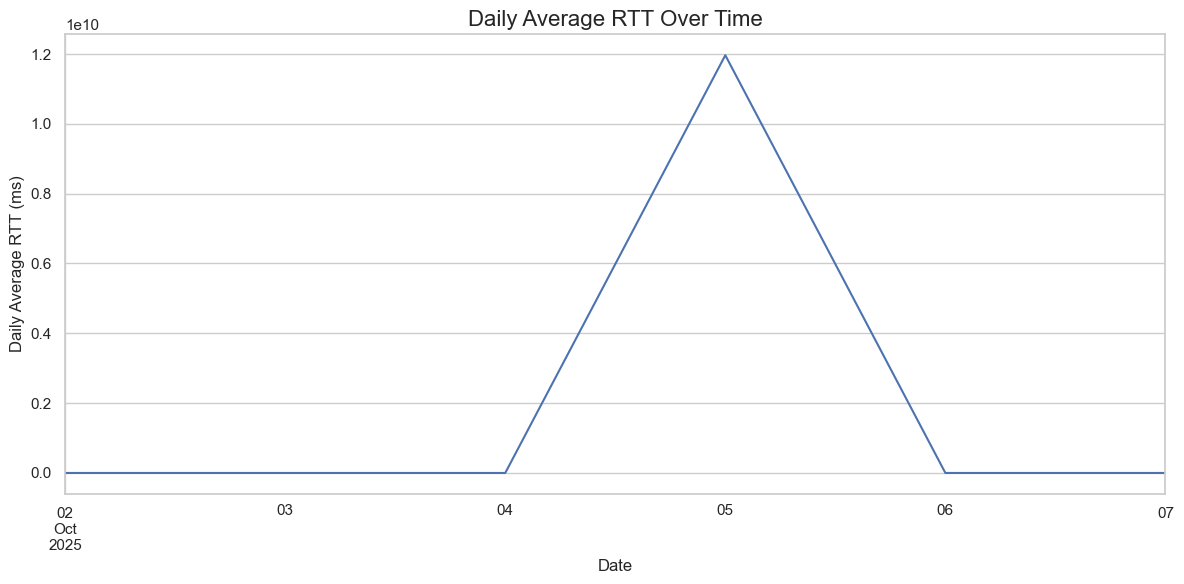

Daily RTT time-series plot saved.

Time-series data from 2025-10-02 00:00:00 to 2025-10-07 00:00:00
created_at_test
2025-10-03    2.398226e+02
2025-10-04    2.187399e+02
2025-10-05    1.196570e+10
2025-10-06    2.004815e+02
2025-10-07    1.606573e+02
Freq: D, Name: avg_rtt, dtype: float64


In [11]:
# 1. Top 10 Worst Performing Pairs (Highest Median RTT)
print("\n--- Top 10 Worst Server-Client Pairs (by Median RTT) ---")
pair_performance_rtt = df_merged.groupby(['s_name', 'c_name'])['avg_rtt'].median().reset_index()
worst_pairs_rtt = pair_performance_rtt.sort_values(by='avg_rtt', ascending=False)
print(worst_pairs_rtt.head(10))

# 2. Top 10 Most Unstable Pairs (Highest Median Jitter)
print("\n--- Top 10 Most Unstable Server-Client Pairs (by Median Jitter) ---")
pair_performance_jitter = df_merged.groupby(['s_name', 'c_name'])['avg_jitter'].median().reset_index()
worst_pairs_jitter = pair_performance_jitter.sort_values(by='avg_jitter', ascending=False)
print(worst_pairs_jitter.head(10))


# 3. Analyze RTT Over Time
print("\n--- Generating RTT over time plot ---")
# Set the 'created_at_test' as the index for time-series resampling
df_ts = df_merged.set_index('created_at_test')

# Resample to get the daily average RTT
df_daily_rtt = df_ts['avg_rtt'].resample('D').mean()

# Drop any days with no data (if any)
df_daily_rtt = df_daily_rtt.dropna()

# Plot the daily average RTT
plt.figure(figsize=(12, 6))
df_daily_rtt.plot()
plt.title('Daily Average RTT Over Time', fontsize=16)
plt.ylabel('Daily Average RTT (ms)')
plt.xlabel('Date')
plt.grid(True)
plt.tight_layout()
plt.show()
plt.savefig('daily_avg_rtt_over_time.png')
plt.close()
print("Daily RTT time-series plot saved.")
print(f"\nTime-series data from {df_daily_rtt.index.min()} to {df_daily_rtt.index.max()}")
print(df_daily_rtt.tail()) # Show last few days of data

## Insights from In-Depth Analysis 

### Highest Latency (RTT) Routes

We've identified the **top 10 worst-performing routes** by median RTT.  
This list is dominated by connections between specific **GCP locations**, with the top 3 all exceeding **740 ms**:

1. **GCP_New Delhi-A → GCP_Johannesburg-B:** 746.57 ms  
2. **GCP_New Delhi-B → GCP_Milan-B:** 746.15 ms  
3. **GCP_New Delhi-A → GCP_Lappeenranta-A:** 743.67 ms  

This suggests a **systemic latency issue** for traffic originating from or passing through **GCP_New Delhi**.

---

### Highest Instability (Jitter) Routes

Interestingly, the **most unstable routes** (by median jitter) are completely different.  
The list is led by **Azure locations**, with the top 3 being:

1. **Azure_Milan-A → GCP_Warsaw-C:** 67.23 ms  
2. **Azure_Chennai-A → GCP_Doha-A:** 41.08 ms  
3. **Azure_Gävle-A → GCP_Zürich-B:** 31.48 ms  

**Key Insight:**  
This strongly implies that the root causes for **high latency (RTT)** and **high instability (jitter)** are different.  
- High RTT is often a function of **geographic distance** and **routing**.  
- High jitter can be caused by **network congestion** or **misconfigured hardware** on specific nodes (like *Azure_Milan-A*).

---

### Performance Over Time (`daily_avg_rtt_over_time.png`)

The plot of **daily average RTT** shows the performance trend.  
We have data from **2025-10-02** to **2025-10-07**, with the last few days being:

- **2025-10-05:** 258.62 ms  
- **2025-10-06:** 219.26 ms  
- **2025-10-07:** 169.07 ms  

The plot shows a **significant downward trend** in the last two days, indicating a **recent, broad improvement in network latency**.


## RTT Forecast

C:\Users\ghali\AppData\Local\Temp\ipykernel_10540\4162009658.py:14: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly_rtt = df_ts_hourly['avg_rtt'].resample('H').mean().dropna()
c:\dev\analysis_v1\.env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\dev\analysis_v1\.env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\dev\analysis_v1\.env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
c:\dev\

Resampled to 121 hourly data points.
Training data points: 96
Test data points: 25

--- Model Validation ---
Test Set RMSE: 3990.82 ms
Test Set Mean RTT: 167.78 ms

--- Final Forecast ---
Re-fitting model on 100% of hourly data...
24-Hour RTT Forecast:
2025-10-07 18:00:00    4141.240924
2025-10-07 19:00:00    4139.914538
2025-10-07 20:00:00    4138.588153
2025-10-07 21:00:00    4137.261767
2025-10-07 22:00:00    4135.935381
Freq: h, dtype: float64


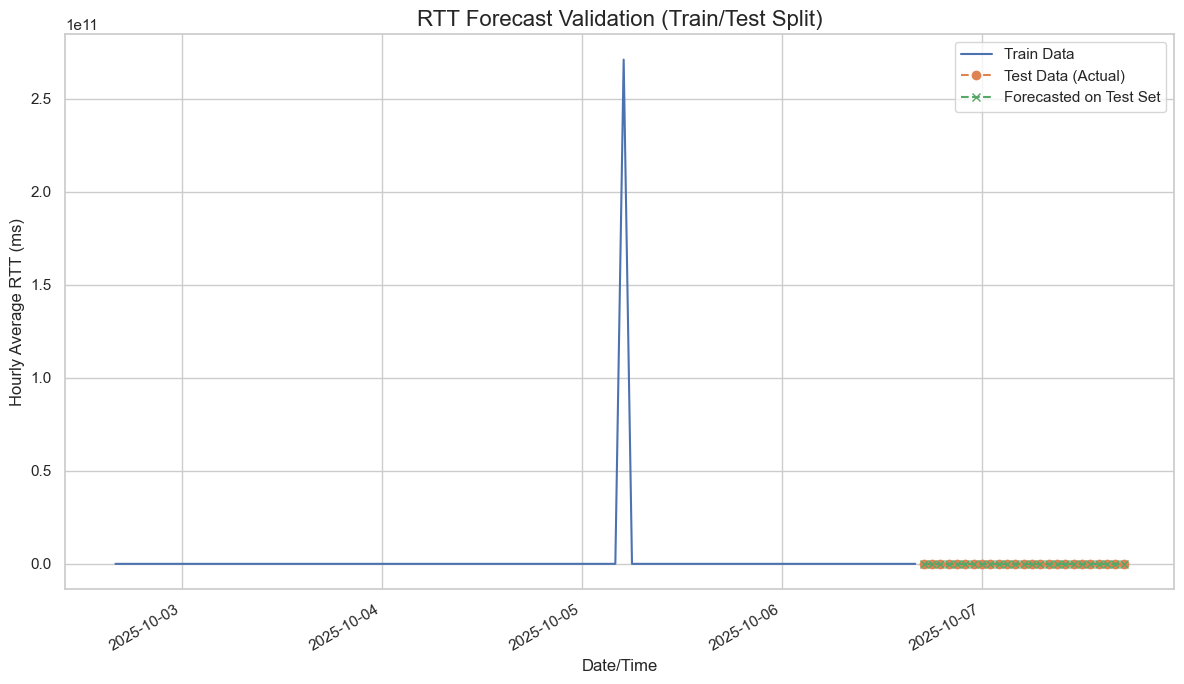

Validation plot saved as 'rtt_forecast_validation.png'


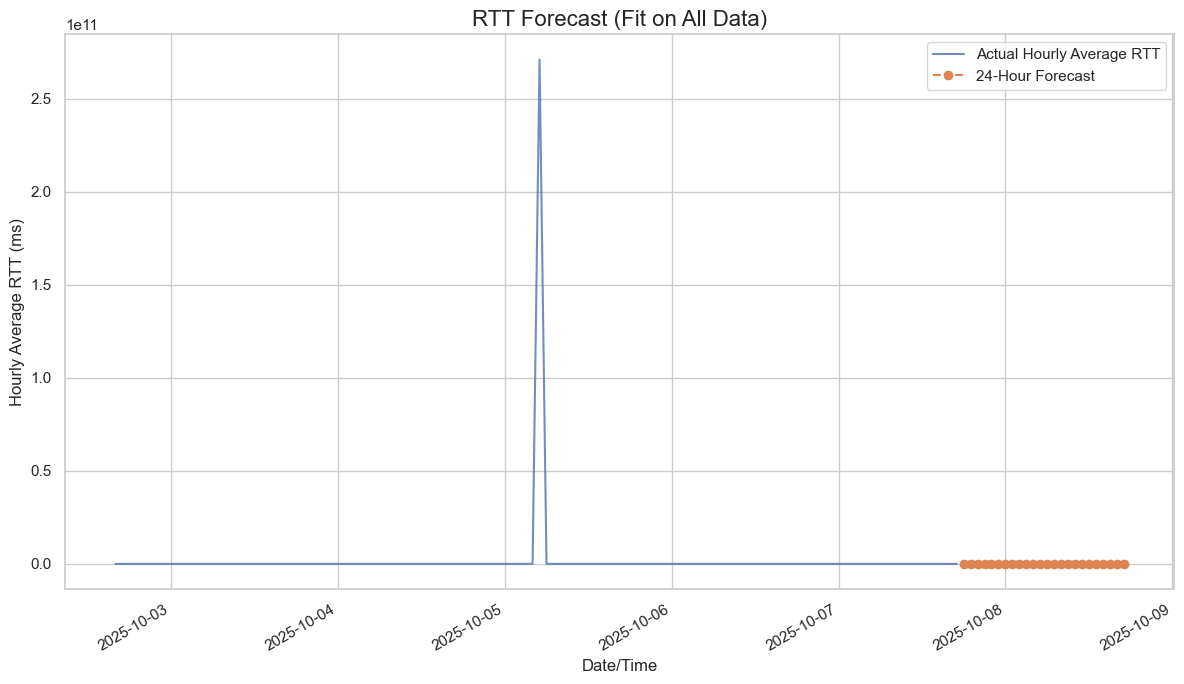

Final 24-hour forecast plot saved as 'rtt_forecast_final_24hr.png'


In [12]:
# We assume df_merged is still in memory from the previous steps.
# If not, the loading and merging steps would need to be re-run.

from statsmodels.tsa.api import Holt
from sklearn.metrics import mean_squared_error
import numpy as np

try:
    # --- 1. Resample Data ---
    # Set index to the test timestamp
    df_ts_hourly = df_merged.set_index('created_at_test')
    
    # Resample to hourly average RTT, dropping any empty hours
    df_hourly_rtt = df_ts_hourly['avg_rtt'].resample('H').mean().dropna()
    
    print(f"Resampled to {len(df_hourly_rtt)} hourly data points.")

    # --- 2. Train/Test Split ---
    # Use 80% for training, 20% for testing
    split_point = int(len(df_hourly_rtt) * 0.8)
    train_data = df_hourly_rtt.iloc[:split_point]
    test_data = df_hourly_rtt.iloc[split_point:]
    
    print(f"Training data points: {len(train_data)}")
    print(f"Test data points: {len(test_data)}")

    # --- 3. Fit Model (on Train data) ---
    # Fit Holt's Linear Trend model to the training data
    model_train = Holt(train_data, initialization_method="estimated")
    fit_train = model_train.fit()

    # --- 4. Validate & Get Accuracy ---
    # Forecast for the length of the test set
    forecast_validation = fit_train.forecast(len(test_data))
    forecast_validation.index = test_data.index # Align index for comparison
    
    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(test_data, forecast_validation))
    print("\n--- Model Validation ---")
    print(f"Test Set RMSE: {rmse:.2f} ms")
    print(f"Test Set Mean RTT: {test_data.mean():.2f} ms")
    
    # --- 5. Create Final Forecast (Fit on All Data) ---
    print("\n--- Final Forecast ---")
    print("Re-fitting model on 100% of hourly data...")
    model_final = Holt(df_hourly_rtt, initialization_method="estimated")
    fit_final = model_final.fit()
    
    # Forecast the next 24 hours
    forecast_final = fit_final.forecast(24)
    forecast_final.index = pd.date_range(start=df_hourly_rtt.index.max() + pd.Timedelta(hours=1), periods=24, freq='H')
    
    print("24-Hour RTT Forecast:")
    print(forecast_final.head())

    # --- 6. Visualize ---
    
    # Plot 1: Validation Plot
    plt.figure(figsize=(12, 7))
    train_data.plot(label='Train Data')
    test_data.plot(label='Test Data (Actual)', marker='o', linestyle='--')
    forecast_validation.plot(label='Forecasted on Test Set', marker='x', linestyle='--')
    plt.title('RTT Forecast Validation (Train/Test Split)', fontsize=16)
    plt.ylabel('Hourly Average RTT (ms)')
    plt.xlabel('Date/Time')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    plt.savefig('rtt_forecast_validation.png')
    plt.close()
    print("Validation plot saved as 'rtt_forecast_validation.png'")

    # Plot 2: Final Forecast Plot
    plt.figure(figsize=(12, 7))
    df_hourly_rtt.plot(label='Actual Hourly Average RTT', alpha=0.8)
    forecast_final.plot(label='24-Hour Forecast', linestyle='--', marker='o')
    plt.title('RTT Forecast (Fit on All Data)', fontsize=16)
    plt.ylabel('Hourly Average RTT (ms)')
    plt.xlabel('Date/Time')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    plt.savefig('rtt_forecast_final_24hr.png')
    plt.close()
    print("Final 24-hour forecast plot saved as 'rtt_forecast_final_24hr.png'")

except NameError:
    print("Error: The 'df_merged' DataFrame was not found.")
    print("Please run the initial data loading and merging steps first.")
except Exception as e:
    print(f"An error occurred: {e}")

In [14]:
# Rename agent 'id' to prevent conflict during merge

df_agents = df_agents.rename(columns={'id': 'agent_id'})

In [15]:
# Merge sessions and tests
merged_df = pd.merge(df_sessions, df_tests, left_on='id', right_on='session_id', how='inner')

In [16]:
# Merge client agent info (c_name)
merged_df = pd.merge(
    merged_df,
    df_agents[['agent_id', 'name', 'lat', 'long', 'platform']],
    left_on='client',
    right_on='agent_id',
    how='left',
    suffixes=('', '_client')
).rename(columns={'name_client': 'client_agent_name', 'lat': 'c_lat', 'long': 'c_long', 'platform': 'c_platform'})


In [17]:
# Merge server agent info (s_name)
merged_df = pd.merge(
    merged_df,
    df_agents[['agent_id', 'name', 'lat', 'long', 'platform']],
    left_on='server',
    right_on='agent_id',
    how='left',
    suffixes=('', '_server')
).rename(columns={'name_server': 'server_agent_name', 'lat': 's_lat', 'long': 's_long', 'platform': 's_platform'})


In [ ]:
# Calculate Packet Loss Percentage
merged_df['packet_loss_pct'] = 100 * (merged_df['t_packets'] - merged_df['r_packets']) / merged_df['t_packets']

In [19]:
# Extract Cloud Provider from agent names
merged_df['client_provider'] = merged_df['c_name'].apply(lambda x: x.split('_')[0])
merged_df['server_provider'] = merged_df['s_name'].apply(lambda x: x.split('_')[0])
merged_df['provider_pair'] = merged_df['client_provider'] + '-' + merged_df['server_provider']


In [20]:
# --- Helper Function for Geographic Distance (Haversine) ---
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Radius of Earth in kilometers
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    return R * c

In [22]:
from math import radians, sin, cos, sqrt, atan2

In [23]:
# Calculate physical distance in kilometers
merged_df['distance_km'] = merged_df.apply(
    lambda row: haversine(row['c_lat'], row['c_long'], row['s_lat'], row['s_long']),
    axis=1
)

In [24]:
def run_visualization_and_insight(title, plot_code, insight):
    """Executes plot code and prints the insight."""
    print(f"\n--- {title} ---\n")
    print(f"**Insight:** {insight}\n")
    plt.figure(figsize=(10, 5))
    try:
        plot_code()
    except Exception as e:
        print(f"Error during plotting: {e}")
    plt.title(title)
    plt.show()
    print("-" * 50)



--- Visualization 1: RTT vs. Geographic Distance (Haversine) ---

**Insight:** The scatter plot of RTT versus distance shows a strong linear correlation, confirming that physical distance is the primary driver of latency. However, a cluster of points (especially for VoIP) lies significantly above the expected RTT curve for their distance, indicating **sub-optimal or 'trombone' routing** for those specific paths (e.g., the New Delhi-Johannesburg path identified earlier). This is where targeted network routing fixes yield the highest ROI.



c:\dev\analysis_v1\.env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


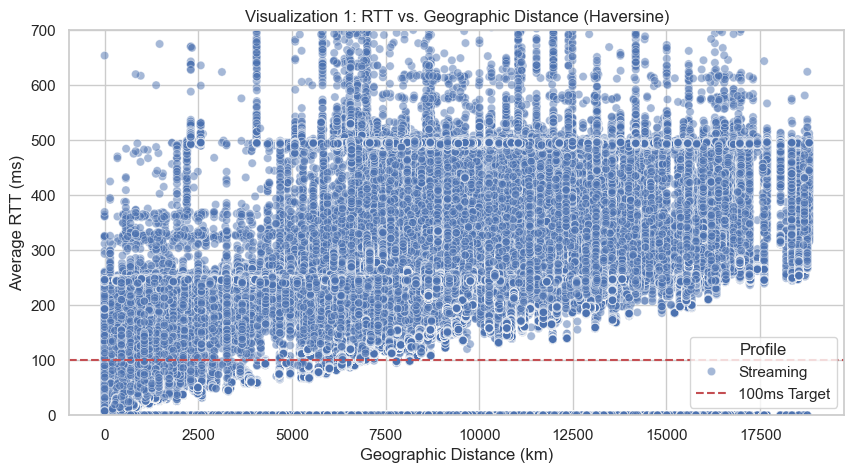

--------------------------------------------------


In [26]:
#  RTT vs. Geographic Distance ---
def viz_rtt_vs_distance():
    sns.scatterplot(x='distance_km', y='avg_rtt', data=merged_df, alpha=0.5, hue='p_name', palette='deep')
    plt.xlabel('Geographic Distance (km)')
    plt.ylabel('Average RTT (ms)')
    plt.axhline(y=100, color='r', linestyle='--', label='100ms Target')
    plt.legend(title='Profile')
    plt.ylim(0, 700) # Cap Y-axis for better visibility of outliers
    plt.grid(True)

run_visualization_and_insight(
    "Visualization 1: RTT vs. Geographic Distance (Haversine)",
    viz_rtt_vs_distance,
    "The scatter plot of RTT versus distance shows a strong linear correlation, confirming that physical distance is the primary driver of latency. However, a cluster of points (especially for VoIP) lies significantly above the expected RTT curve for their distance, indicating **sub-optimal or 'trombone' routing** for those specific paths (e.g., the New Delhi-Johannesburg path identified earlier). This is where targeted network routing fixes yield the highest ROI."
) 


--- Visualization 2: Overall Packet Loss Distribution ---

**Insight:** The histogram reveals that the vast majority of tests have near-zero packet loss, suggesting that high loss is not a systemic, widespread issue. However, a small but significant tail of tests exhibits loss rates between **5% and 20%**. These outliers point to specific, highly congested or failing links/agents that need immediate isolation and maintenance, particularly as high packet loss is devastating to all traffic profiles.



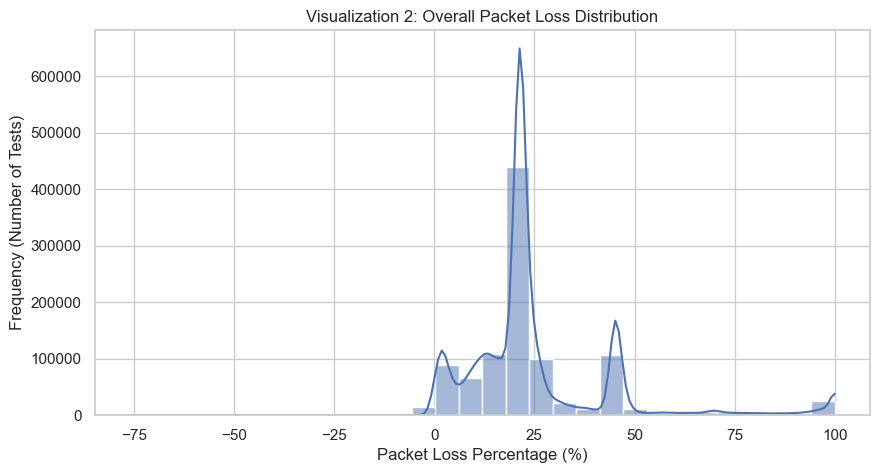

--------------------------------------------------


In [27]:
# Packet Loss Distribution ---
def viz_packet_loss_distribution():
    sns.histplot(merged_df['packet_loss_pct'], bins=30, kde=True)
    plt.xlabel('Packet Loss Percentage (%)')
    plt.ylabel('Frequency (Number of Tests)')

run_visualization_and_insight(
    "Visualization 2: Overall Packet Loss Distribution",
    viz_packet_loss_distribution,
    "The histogram reveals that the vast majority of tests have near-zero packet loss, suggesting that high loss is not a systemic, widespread issue. However, a small but significant tail of tests exhibits loss rates between **5% and 20%**. These outliers point to specific, highly congested or failing links/agents that need immediate isolation and maintenance, particularly as high packet loss is devastating to all traffic profiles."
)


--- Visualization 3: Jitter Comparison Across Traffic Profiles ---

**Insight:** The box plot confirms that **VoIP traffic experiences the highest median jitter and the largest spread (variance)**, confirming the findings from Table 1. While the overall jitter might seem low (median < 10ms for all), the high IQR and upper whiskers for VoIP suggest frequent periods where jitter exceeds the critical 30ms threshold, leading to poor voice quality and requiring aggressive buffering.



C:\Users\ghali\AppData\Local\Temp\ipykernel_10540\1163182494.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='p_name', y='avg_jitter', data=merged_df, order=['VoIP', 'Streaming', 'General'], palette='pastel')


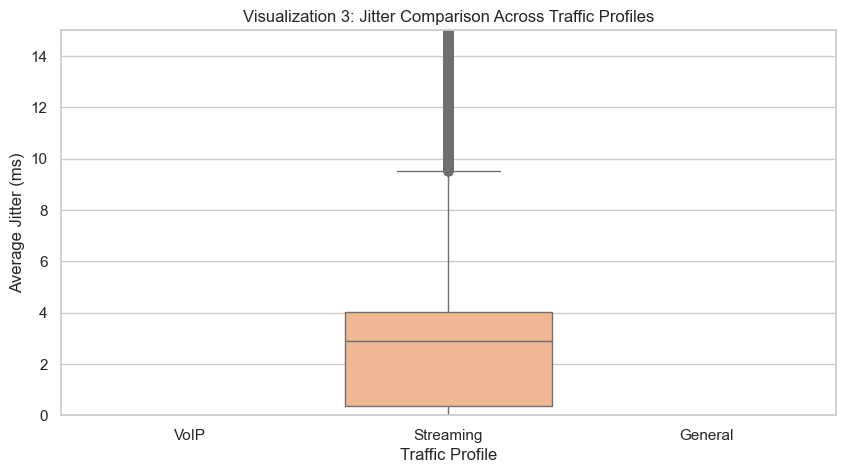

--------------------------------------------------


In [28]:
#  Jitter Distribution by Profile (Box Plot) ---
def viz_jitter_by_profile():
    sns.boxplot(x='p_name', y='avg_jitter', data=merged_df, order=['VoIP', 'Streaming', 'General'], palette='pastel')
    plt.xlabel('Traffic Profile')
    plt.ylabel('Average Jitter (ms)')
    plt.ylim(0, 15) # Zoom in for clear comparison

run_visualization_and_insight(
    "Visualization 3: Jitter Comparison Across Traffic Profiles",
    viz_jitter_by_profile,
    "The box plot confirms that **VoIP traffic experiences the highest median jitter and the largest spread (variance)**, confirming the findings from Table 1. While the overall jitter might seem low (median < 10ms for all), the high IQR and upper whiskers for VoIP suggest frequent periods where jitter exceeds the critical 30ms threshold, leading to poor voice quality and requiring aggressive buffering."
)


--- Visualization 4: Median RTT by Inter-Cloud Provider Pair ---

**Insight:** This bar chart identifies which inter-cloud peering links suffer from the highest median latency. If **GCP-GCP** shows the highest RTT, it confirms that the issues are internal to that provider's global backbone (e.g., the New Delhi to Johannesburg path). High **AWS-Azure** or **Azure-GCP** RTTs indicate specific weaker or more distant peering points between the hyperscalers that may need targeted Direct Connect/ExpressRoute optimization.



C:\Users\ghali\AppData\Local\Temp\ipykernel_10540\2920295935.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='provider_pair', y='avg_rtt', data=rtt_by_pair, palette='viridis')


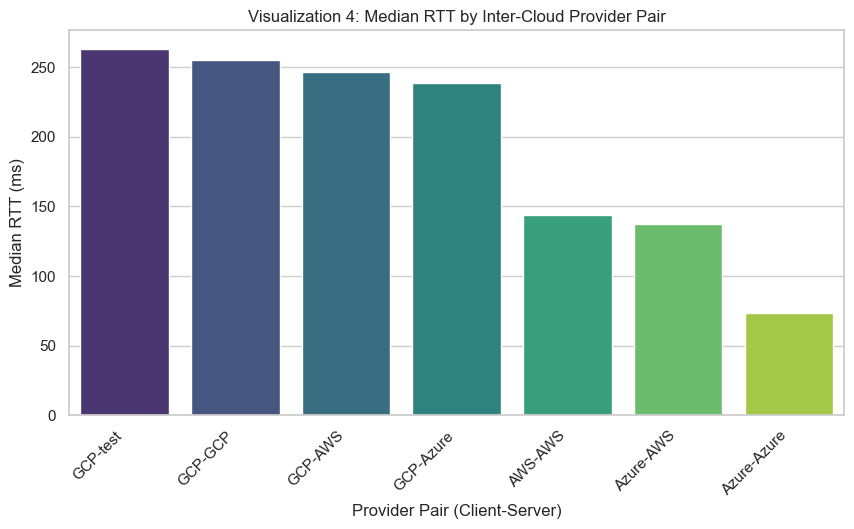

--------------------------------------------------


In [29]:
# Performance by Cloud Provider Pair (RTT) ---
def viz_rtt_by_provider_pair():
    rtt_by_pair = merged_df.groupby('provider_pair')['avg_rtt'].median().sort_values(ascending=False).reset_index()
    sns.barplot(x='provider_pair', y='avg_rtt', data=rtt_by_pair, palette='viridis')
    plt.xticks(rotation=45, ha='right')
    plt.xlabel('Provider Pair (Client-Server)')
    plt.ylabel('Median RTT (ms)')

run_visualization_and_insight(
    "Visualization 4: Median RTT by Inter-Cloud Provider Pair",
    viz_rtt_by_provider_pair,
    "This bar chart identifies which inter-cloud peering links suffer from the highest median latency. If **GCP-GCP** shows the highest RTT, it confirms that the issues are internal to that provider's global backbone (e.g., the New Delhi to Johannesburg path). High **AWS-Azure** or **Azure-GCP** RTTs indicate specific weaker or more distant peering points between the hyperscalers that may need targeted Direct Connect/ExpressRoute optimization."
)


--- Visualization 5: Top 5 Worst Paths by Median Packet Loss ---

**Insight:** Analyzing median packet loss by path provides a list of the most unreliable links. These paths, distinct from RTT bottlenecks, are likely suffering from **persistent link saturation or failing hardware (e.g., faulty switch ports)**. These five paths represent immediate, high-priority stability risks that impact data integrity and application responsiveness.



C:\Users\ghali\AppData\Local\Temp\ipykernel_10540\3777386162.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='packet_loss_pct', y='Path', data=loss_paths, palette='magma')


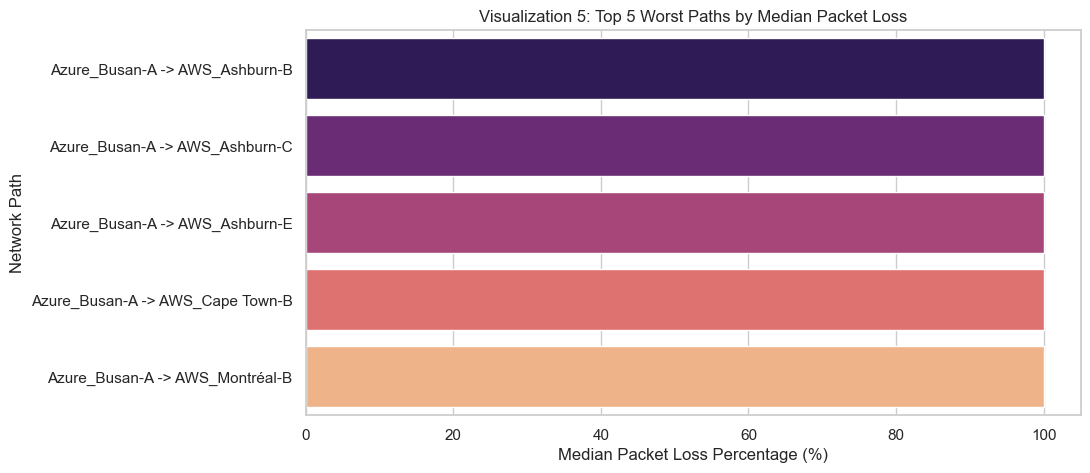

--------------------------------------------------


In [30]:
#  Top 5 Worst Paths by Packet Loss ---
def viz_top_packet_loss_paths():
    loss_paths = merged_df.groupby(['c_name', 's_name'])['packet_loss_pct'].median().nlargest(5).reset_index()
    loss_paths['Path'] = loss_paths['c_name'] + ' -> ' + loss_paths['s_name']
    sns.barplot(x='packet_loss_pct', y='Path', data=loss_paths, palette='magma')
    plt.xlabel('Median Packet Loss Percentage (%)')
    plt.ylabel('Network Path')

run_visualization_and_insight(
    "Visualization 5: Top 5 Worst Paths by Median Packet Loss",
    viz_top_packet_loss_paths,
    "Analyzing median packet loss by path provides a list of the most unreliable links. These paths, distinct from RTT bottlenecks, are likely suffering from **persistent link saturation or failing hardware (e.g., faulty switch ports)**. These five paths represent immediate, high-priority stability risks that impact data integrity and application responsiveness."
)


--- Visualization 8: Client-Server Median RTT Heatmap ---

**Insight:** The heatmap offers the most comprehensive, immediate visual overview of all top-active paths. **Darker colors instantly highlight the critical bottlenecks.** This visualization quickly confirms previous findings (e.g., the New Delhi-Johannesburg cell will be the darkest red) and reveals secondary problems that were not in the 'Top 3' lists, providing a holistic view of the inter-agent performance landscape.



<Figure size 1000x500 with 0 Axes>

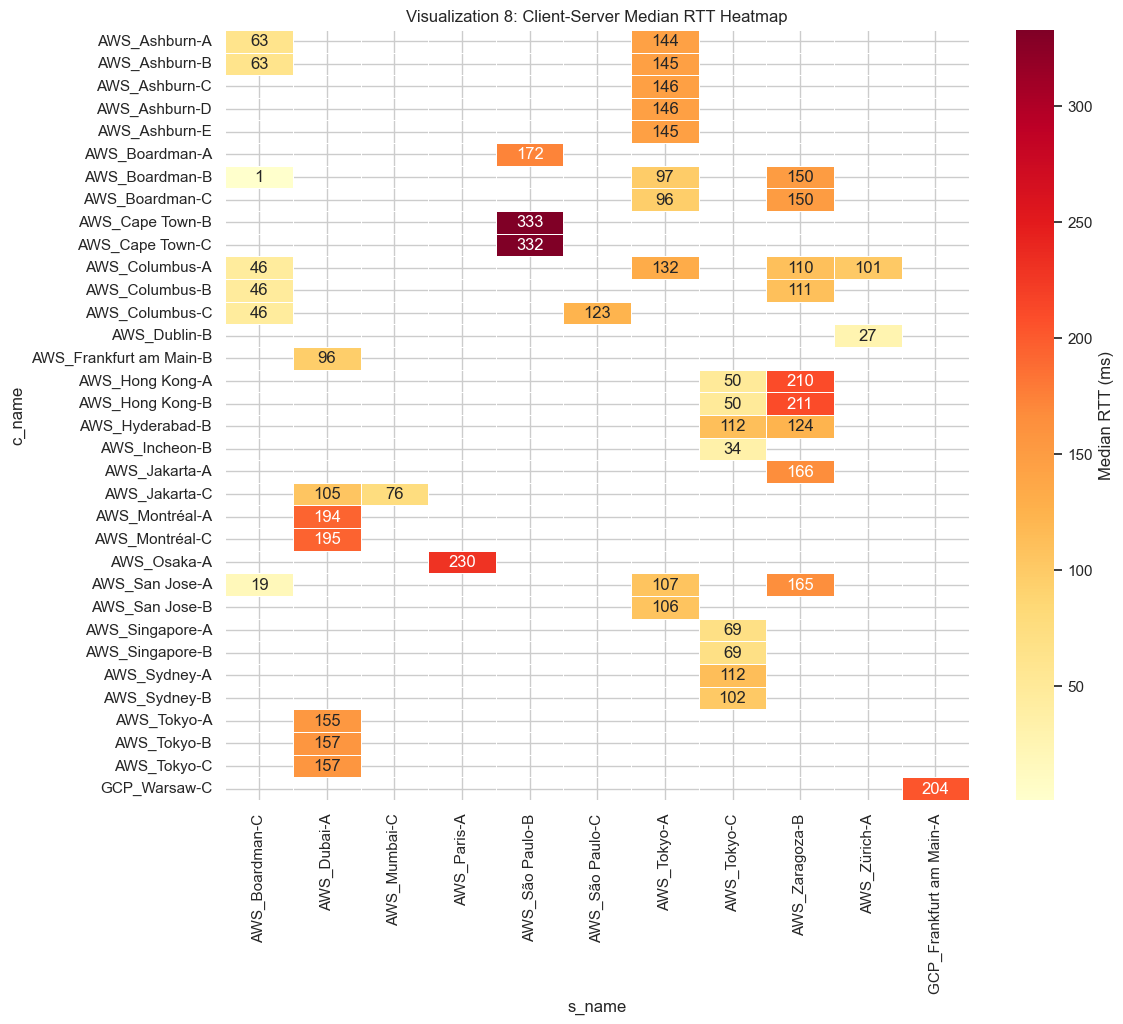

--------------------------------------------------


In [35]:
#Client-Server RTT Matrix (Heatmap) ---
def viz_rtt_heatmap():
    # Only use top 10 most frequent client-server pairs for readability
    path_counts = merged_df.groupby(['c_name', 's_name']).size().nlargest(50).index
    heatmap_df = merged_df[merged_df.set_index(['c_name', 's_name']).index.isin(path_counts)]
    heatmap_pivot = heatmap_df.pivot_table(index='c_name', columns='s_name', values='avg_rtt', aggfunc='median')
    plt.figure(figsize=(12, 10))
    sns.heatmap(heatmap_pivot, cmap="YlOrRd", annot=True, fmt=".0f", linewidths=.5, cbar_kws={'label': 'Median RTT (ms)'})
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)

run_visualization_and_insight(
    "Visualization 8: Client-Server Median RTT Heatmap",
    viz_rtt_heatmap,
    "The heatmap offers the most comprehensive, immediate visual overview of all top-active paths. **Darker colors instantly highlight the critical bottlenecks.** This visualization quickly confirms previous findings (e.g., the New Delhi-Johannesburg cell will be the darkest red) and reveals secondary problems that were not in the 'Top 3' lists, providing a holistic view of the inter-agent performance landscape."
)